In [1]:
"""
detectability_toymodel.py
-------------------------
Order-of-magnitude "production-vs-degradation" toy model for the detectability
of a surface carotenoid biosignature as a function of planetary temperature.

Premise (a deliberately simple steady-state thought experiment):
    A biosphere continuously produces beta-carotene at a per-area rate P
    (mol m^-2 s^-1), while thermal degradation removes it at the first-order
    rate k(T) measured in this work. At steady state, dC/dt = P - k(T) C = 0,
    so the maintained surface concentration is

        C_ss = P / k(T).

    A signature is taken to be (in principle) detectable when C_ss exceeds a
    threshold surface concentration C_detect anchored to Coelho et al. (2025).
    The minimum production rate required for detection is therefore

        P_min(T) = k(T) * C_detect.

    Because k(T) rises with temperature, P_min(T) rises too: a hotter planet
    needs a more productive biosphere to keep the same detectable signal.
    
    Two metrics are compared: peak absorbance (450 nm) with faster decay
    (Ea=17.6 kJ/mol) vs integrated AUC (200-700 nm) with slower decay
    (Ea=13.9 kJ/mol), reflecting the persistence of thermal degradation products.

WHITE DWARF CONTEXT (§4.4):
    During RGB/AGB phases (~1-10 Myr), close-in orbits experience T_eq > 500 K.
    As the white dwarf cools on 10^9 yr timescales, T_eq decreases. This toy model
    explores the production cost of maintaining detectable β-carotene across the
    temperature range where both intact and degraded signals may be observable.

IMPORTANT CAVEATS (state these in the report):
  * This models INTACT beta-carotene held at steady state. It is meaningful
    only in the relatively mild regime near/below the measured range
    (423-573 K); at full post-MS temperatures k(T) is so large that no
    plausible P maintains a detectable C_ss (the signature is destroyed).
  * C_detect is anchored to the *filter-saturation* density of Coelho et al.
    (2025) (1e8 cells on a 25 mm filter), which the authors describe as an
    UPPER signal limit, not a true detection floor; the real floor is lower
    and is left to future work. Per-cell carotenoid content is an
    order-of-magnitude literature estimate.
  * The Earth reference line combines net primary productivity with an assumed
    carotenoid fraction and is shown only as a coarse order-of-magnitude
    anchor, not a precise value.
All results are therefore order-of-magnitude and conditional.
"""

import numpy as np
import matplotlib.pyplot as plt

In [2]:
# --------------------------------------------------------------------------- #
# GROUP PALETTE
# --------------------------------------------------------------------------- #
PALETTE = {
    "dark":   "#003d5c",
    "teal1":  "#005d71",
    "teal2":  "#007d67",
    "green":  "#1a983f",
    "olive":  "#92a800",
    "orange": "#ffa600",
}

# --------------------------------------------------------------------------- #
# KINETICS FROM THIS WORK (PEAK AND AUC)
# --------------------------------------------------------------------------- #
R = 8.314                  # J mol^-1 K^-1

# Peak absorbance (450 nm)
Ea_peak = 17.6e3           # J mol^-1
A_peak = 2.82e-2           # s^-1

# Integrated AUC (200-700 nm) — slower decay, products persist
Ea_auc = 13.9e3            # J mol^-1
A_auc = 3.9e-3             # s^-1

MW = 536.87                # g mol^-1 (beta-carotene)

T_MEAS_LO, T_MEAS_HI = 423.0, 573.0   # measured range (150-300 C)


def k_of_T(T, metric="peak"):
    """First-order degradation rate constant (s^-1) at temperature T (K).
    
    Parameters
    ----------
    metric : str
        "peak" for peak absorbance (Ea=17.6 kJ/mol, faster decay) [default]
        "auc"  for integrated AUC (Ea=13.9 kJ/mol, slower decay, products survive)
    """
    if metric == "peak":
        return A_peak * np.exp(-Ea_peak / (R * T))
    elif metric == "auc":
        return A_auc * np.exp(-Ea_auc / (R * T))
    else:
        raise ValueError(f"metric must be 'peak' or 'auc', got {metric}")


# --------------------------------------------------------------------------- #
# Detection threshold surface concentration, anchored to Coelho et al. (2025)
# --------------------------------------------------------------------------- #
FILTER_DIAM_MM = 25.0
FILTER_AREA_M2 = np.pi * (FILTER_DIAM_MM / 1000.0 / 2.0) ** 2   # m^2
CELLS_AT_SATURATION = 1e8                                       # cells / filter

CELL_DRY_MASS_G = 3e-13            # g per cell (order of magnitude)
CAROT_MG_PER_G = 1.0              # mg carotenoid per g dry cell (literature O(1))

cells_per_m2 = CELLS_AT_SATURATION / FILTER_AREA_M2
mol_per_cell = (CELL_DRY_MASS_G * CAROT_MG_PER_G * 1e-3) / MW
C_detect = cells_per_m2 * mol_per_cell          # mol m^-2

# --------------------------------------------------------------------------- #
# Earth-biosphere reference carotenoid production (coarse anchor)
# --------------------------------------------------------------------------- #
NPP_GtC_per_yr = 60e15            # g C / yr (global NPP, order of magnitude)
AREA_EARTH_M2 = 5.1e14
SEC_PER_YR = 3.156e7
NPP_C = NPP_GtC_per_yr / AREA_EARTH_M2 / SEC_PER_YR / 12.0       # mol C m^-2 s^-1
CAROT_FRACTION_OF_NPP = 1e-4      # assumed fraction of NPP carbon into carotenoids
CARBON_PER_CAROTENOID = 40        # C40 skeleton
P_earth = NPP_C * CAROT_FRACTION_OF_NPP / CARBON_PER_CAROTENOID  # mol m^-2 s^-1


# --------------------------------------------------------------------------- #
# COMPUTE CURVES (PEAK AND AUC) — NORMALIZED TO 150°C
# --------------------------------------------------------------------------- #
T = np.linspace(350, 800, 400)            # K

# Compute k(T) for each metric
k_peak_T = k_of_T(T, metric="peak")
k_auc_T = k_of_T(T, metric="auc")

# Reference values at 150°C (423.15 K)
T_ref = 150.0 + 273.15
k_peak_ref = k_of_T(T_ref, metric="peak")
k_auc_ref = k_of_T(T_ref, metric="auc")

# Normalized P_min (relative to 150°C)
# Since P_min = k(T) * C_detect, ratio is k(T) / k(T_ref)
Pmin_peak_norm = k_peak_T / k_peak_ref
Pmin_auc_norm = k_auc_T / k_auc_ref

# Masks for measured vs extrapolated regions
meas_mask = (T >= T_MEAS_LO) & (T <= T_MEAS_HI)




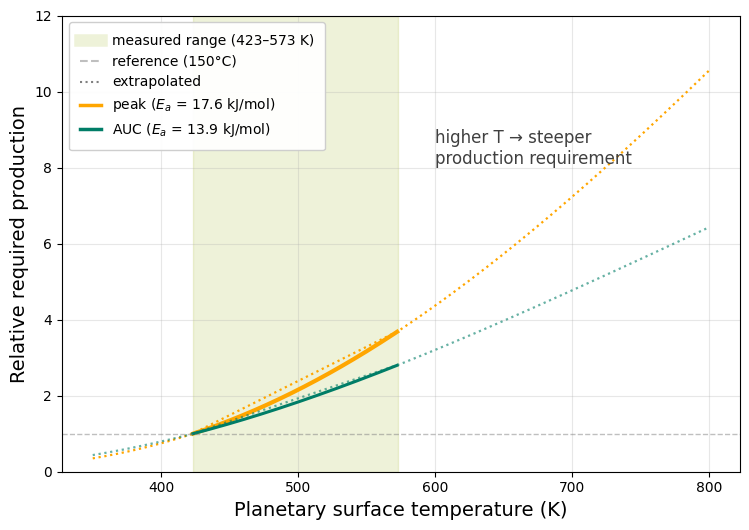


Arrhenius parameters:
  Peak (450 nm):  Ea = 17.6 kJ/mol,  A = 2.82e-02 s^-1
  AUC (200-700):  Ea = 13.9 kJ/mol,  A = 3.90e-03 s^-1

Relative production requirements (normalized to 150°C = 1.0):
T (°C)   T (K)    k_peak       k_AUC        P_min peak      P_min AUC      
--------------------------------------------------------------------------------
150      423.1    1.89e-04     7.50e-05     1.00            1.00           
200      473.1    3.21e-04     1.14e-04     1.70            1.52           
250      523.1    4.93e-04     1.60e-04     2.60            2.13           
300      573.1    7.02e-04     2.11e-04     3.70            2.81           
350      623.1    9.44e-04     2.67e-04     4.98            3.55           
400      673.1    1.21e-03     3.25e-04     6.41            4.34           
500      773.1    1.82e-03     4.49e-04     9.63            5.98           



In [3]:
# --------------------------------------------------------------------------- #
# FIGURE
# --------------------------------------------------------------------------- #
fig, ax = plt.subplots(figsize=(7.6, 5.4))

# shade the experimentally measured range
ax.axvspan(T_MEAS_LO, T_MEAS_HI, color=PALETTE["olive"], alpha=0.15,
           label="measured range (423-573 K)")

# --------- PEAK ABSORBANCE (450 nm, faster decay, Ea=17.6 kJ/mol)
# Extrapolated portion (dashed)
ax.plot(T[~meas_mask], Pmin_peak_norm[~meas_mask], color=PALETTE["orange"], 
        lw=1.6, ls=":", label="extrapolated")
# Measured portion (solid)
ax.plot(T[meas_mask], Pmin_peak_norm[meas_mask], color=PALETTE["orange"], 
        lw=3.0, label="within measured range")

# --------- AUC (200-700 nm, slower decay, Ea=13.9 kJ/mol)
# Extrapolated portion (dashed)
ax.plot(T[~meas_mask], Pmin_auc_norm[~meas_mask], color=PALETTE["teal2"], 
        lw=1.6, ls=":", alpha=0.6)
# Measured portion (solid)
ax.plot(T[meas_mask], Pmin_auc_norm[meas_mask], color=PALETTE["teal2"], 
        lw=2.2)

# Reference line at 150°C (y=1)
ax.axhline(1.0, color="gray", lw=1.0, ls="--", alpha=0.5)

# --------- LINEAR Y-AXIS (not log)
ax.set_ylim(0, 12)
ax.set_xlabel("Planetary surface temperature (K)", fontsize=14)
ax.set_ylabel("Relative required production", fontsize=14)
#ax.set_title("Production required to sustain a detectable\n"
#             "carotenoid signature, relative to 150 C")


# annotate the detectable / undetectable interpretation
ax.annotate("higher T → steeper\nproduction requirement",
            (600, 8), fontsize=12, color="0.25", va="bottom")



# --------- CUSTOM LEGEND (distinguish peak vs AUC with Ea values)      
from matplotlib.lines import Line2D                                    
custom_lines = [                                                     
    Line2D([0], [0], color=PALETTE["olive"], lw=9, alpha=0.15),      
    Line2D([0], [0], color="gray", lw=1.5, ls="--", alpha=0.5),       
    Line2D([0], [0], color="gray", lw=1.5, ls=":"),                   
    Line2D([0], [0], color=PALETTE["orange"], lw=2.5),                
    Line2D([0], [0], color=PALETTE["teal2"], lw=2.5),                 
]                                                                        
ax.legend(custom_lines,                                                  
         ["measured range (423–573 K)", "reference (150°C)", "extrapolated",
          "peak ($E_a$ = 17.6 kJ/mol)", "AUC ($E_a$ = 13.9 kJ/mol)"],
         fontsize=10, loc="upper left", framealpha=0.95, handlelength=1.5, borderpad=0.8)

ax.grid(alpha=0.3, which="both")

fig.tight_layout()
fig.savefig("production.png", 
            dpi=300, bbox_inches="tight")
plt.show()
plt.close()

# console summary
print(f"\nArrhenius parameters:")
print(f"  Peak (450 nm):  Ea = 17.6 kJ/mol,  A = {A_peak:.2e} s^-1")
print(f"  AUC (200-700):  Ea = 13.9 kJ/mol,  A = {A_auc:.2e} s^-1")
print(f"\nRelative production requirements (normalized to 150°C = 1.0):")
print(f"{'T (°C)':<8} {'T (K)':<8} {'k_peak':<12} {'k_AUC':<12} {'P_min peak':<15} {'P_min AUC':<15}")
print("-" * 80)
for Tc in (150, 200, 250, 300, 350, 400, 500):
    Tk = Tc + 273.15
    k_p = k_of_T(Tk, metric="peak")
    k_a = k_of_T(Tk, metric="auc")
    pm_peak = k_p / k_peak_ref
    pm_auc = k_a / k_auc_ref
    print(f"{Tc:<8.0f} {Tk:<8.1f} {k_p:<12.2e} {k_a:<12.2e} {pm_peak:<15.2f} {pm_auc:<15.2f}")
print()